In [33]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *
import torch
from torch.utils.data import DataLoader, random_split
import time
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Real Train: 536, Real Val: 134, Real Test: 65


In [35]:
mosaic_img, mosaic_inst = create_mosaic_real(real_val, indices=[0, 1, 2, 3])

print(f"📦 Formato da imagem do mosaico: {mosaic_img.shape}")
print(f"🏷️ Formato da máscara de instâncias do mosaico: {mosaic_inst.shape}")
print(f"🔢 Total de instâncias únicas no mosaico: {len(np.unique(mosaic_inst)) - 1}")

📦 Formato da imagem do mosaico: (3, 256, 256)
🏷️ Formato da máscara de instâncias do mosaico: (256, 256)
🔢 Total de instâncias únicas no mosaico: 128


In [36]:
def mosaic_tile_inference_demo(mosaic_img, tile_size=128, overlap=32):
    """
    Simula o fatiamento de uma imagem grande em tiles com sobreposição (tiling),
    revelando o desafio das fronteiras para objetos divididos entre os blocos.
    """
    _, H, W = mosaic_img.shape
    stride = tile_size - overlap
    
    tiles = []
    coordinates = []
    
    for y in range(0, H - overlap, stride):
        for x in range(0, W - overlap, stride):
            # Garante que o tile não ultrapasse as bordas da imagem grande
            y_end = min(y + tile_size, H)
            x_end = min(x + tile_size, W)
            y_start = max(0, y_end - tile_size)
            x_start = max(0, x_end - tile_size)
            
            tile = mosaic_img[:, y_start:y_end, x_start:x_end]
            tiles.append(tile)
            coordinates.append((y_start, y_end, x_start, x_end))
            
    return tiles, coordinates

In [37]:
tiles, coords = mosaic_tile_inference_demo(mosaic_img, tile_size=128, overlap=32)

print(f"🧩 Número total de tiles gerados: {len(tiles)}")
print(f"📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: {coords[0]}")
print(f"📦 Formato de cada tile: {tiles[0].shape}")

🧩 Número total de tiles gerados: 9
📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: (0, 128, 0, 128)
📦 Formato de cada tile: (3, 128, 128)


In [38]:
def mosaic_inference_with_fusion(model, large_image, tile_size=128, overlap=32, device='cpu'):
    """
    Realiza inferência em mosaico (tiles) em uma imagem grande com sobreposição
    e aplica fusão de instâncias nas bordas dos tiles baseada em intersecção.
    """
    # Se o modelo não for nulo, garantimos que está em modo de avaliação
    if model is not None:
        model.eval()
        
    C, H, W = large_image.shape
    stride = tile_size - overlap
    
    # Canvas para acumular as predições finais
    global_instances = np.zeros((H, W), dtype=np.int32)
    next_instance_id = 1
    
    for y in range(0, H - overlap, stride):
        for x in range(0, W - overlap, stride):
            y_end = min(y + tile_size, H)
            x_end = min(x + tile_size, W)
            y_start = max(0, y_end - tile_size)
            x_start = max(0, x_end - tile_size)
            
            # Recorta o tile da imagem
            tile = large_image[:, y_start:y_end, x_start:x_end]
            tile_tensor = torch.tensor(tile).unsqueeze(0).float().to(device)
                
            with torch.no_grad():
                # Faz a predição local do tile
                binary_pred = (torch.sigmoid(model(tile_tensor)) > 0.5).float().cpu().numpy()
                pred_mask = np.squeeze(binary_pred[0, 0]).astype(np.uint8)
                
            # Extrai instâncias locais do tile
        
            _, tile_insts = cv.connectedComponents(pred_mask)
            
            # Reatribui IDs globais e resolve conflitos na sobreposição
            for l_id in np.unique(tile_insts)[1:]:
                local_mask = (tile_insts == l_id)
                
                # Olhamos para a região correspondente no canvas global
                existing_canvas_region = global_instances[y_start:y_end, x_start:x_end]
                
                # Pega os IDs e a quantidade de pixels de intersecção de cada um
                overlap_ids, counts = np.unique(existing_canvas_region[local_mask], return_counts=True)
                
                # Filtra o fundo (ID 0)
                valid_mask = overlap_ids > 0
                overlap_ids = overlap_ids[valid_mask]
                counts = counts[valid_mask]

                if len(overlap_ids) > 0:
                    # Pega o ID global com a maior quantidade de pixels sobrepostos
                    best_match_idx = np.argmax(counts)
                    g_id = overlap_ids[best_match_idx]
                    
                    t_mask = (existing_canvas_region == g_id)
                    
                    intersection = counts[best_match_idx] # Já temos a área de intersecção do argmax!
                    min_area = min(t_mask.sum(), local_mask.sum())
                    
                    if min_area > 0 and (intersection / min_area) > 0.5:
                        global_instances[y_start:y_end, x_start:x_end][local_mask] = g_id
                    else:
                        global_instances[y_start:y_end, x_start:x_end][local_mask] = next_instance_id
                        next_instance_id += 1
                else:
                    global_instances[y_start:y_end, x_start:x_end][local_mask] = next_instance_id
                    next_instance_id += 1
                    
    return global_instances

Epoch 1/5 | Loss: 0.2621 | IoU: 0.0282 | Dice: 0.0548
Epoch 2/5 | Loss: 0.1385 | IoU: 0.6562 | Dice: 0.7924
Epoch 3/5 | Loss: 0.1125 | IoU: 0.7106 | Dice: 0.8308
Epoch 4/5 | Loss: 0.1017 | IoU: 0.7366 | Dice: 0.8483
Epoch 5/5 | Loss: 0.0952 | IoU: 0.7515 | Dice: 0.8581
Training time: 3.59 minutes
Média global mAP: 0.3049
Média global Erro Absoluto de Contagem: 20.8358


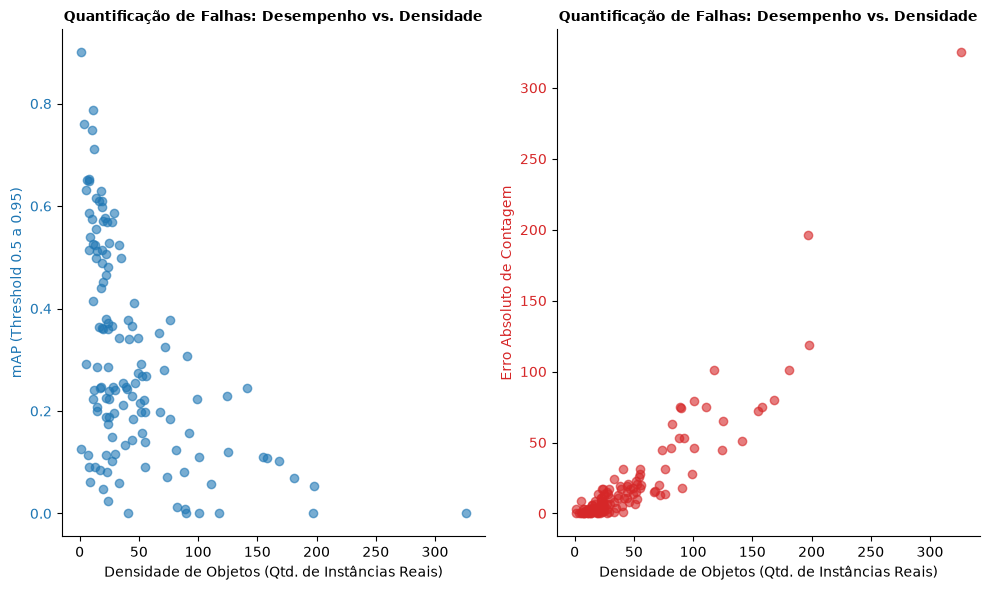

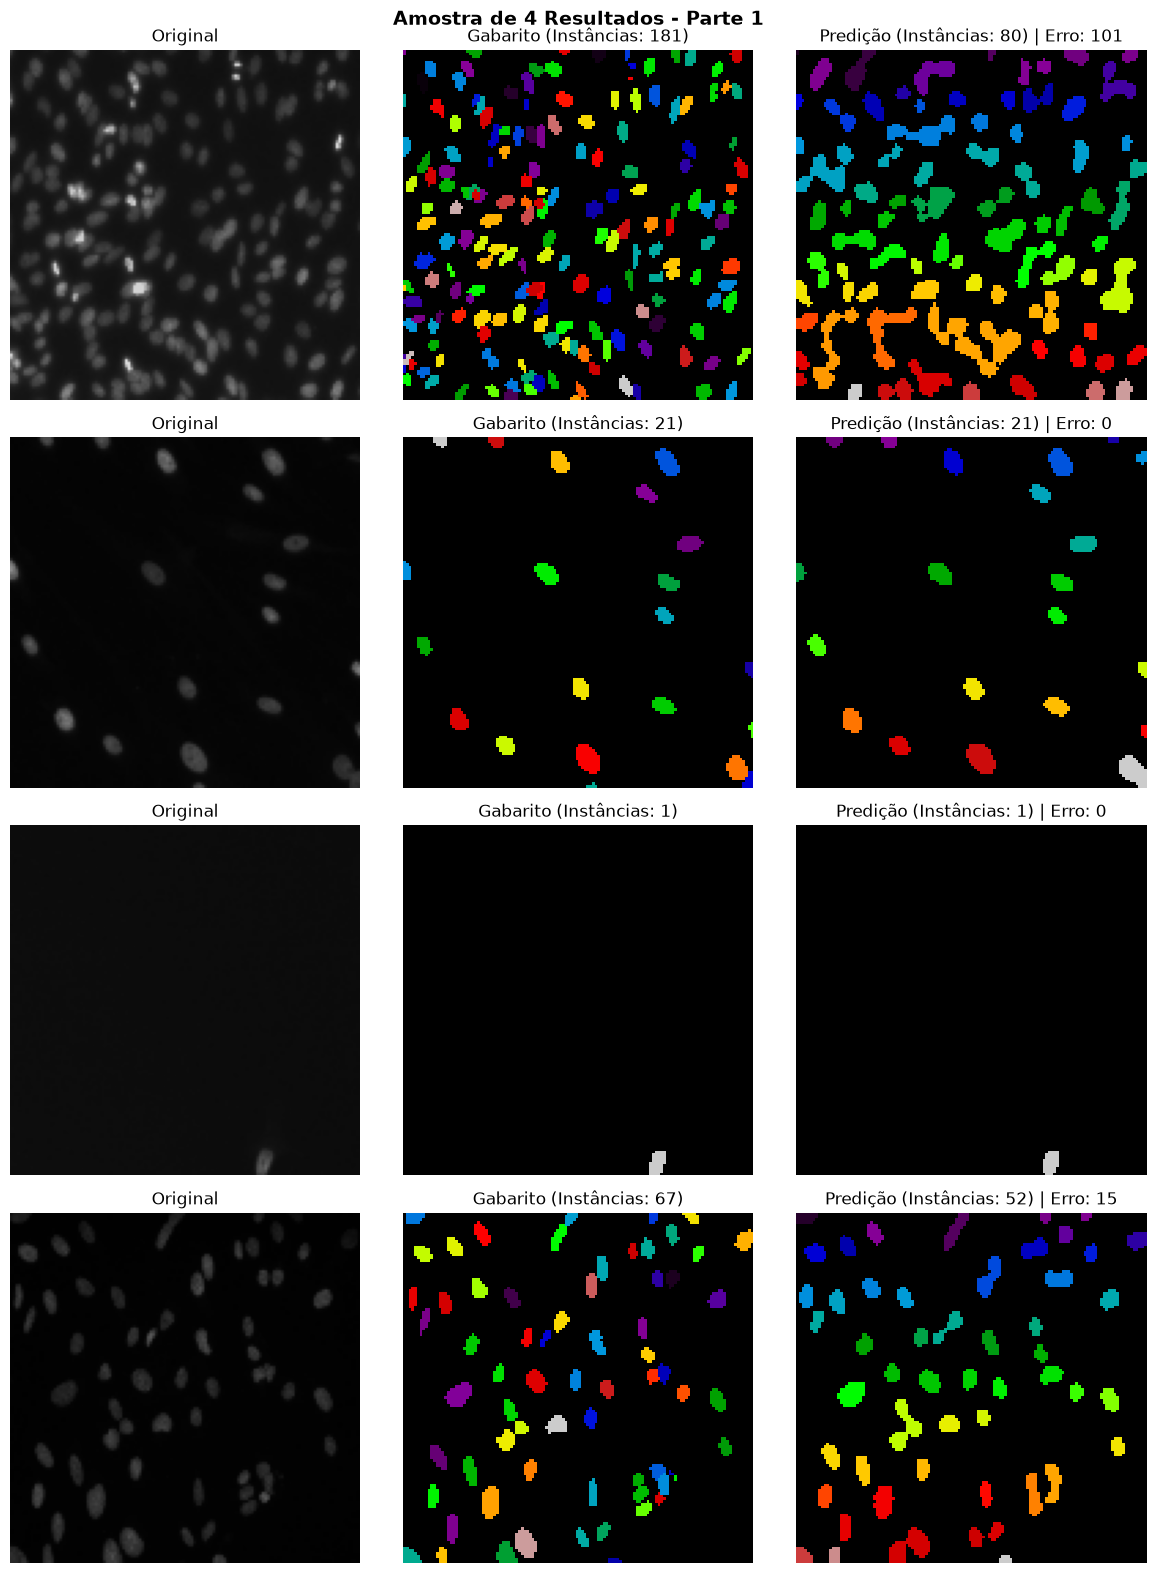

In [ ]:

def mosaic_inference_naive(model, large_image, tile_size=128, overlap=32, device='cpu'):
    """ Inferência ingênua (sem correção) para mostrar o erro na fronteira. """
    if model is not None: model.eval()
    C, H, W = large_image.shape
    stride = tile_size - overlap
    global_instances = np.zeros((H, W), dtype=np.int32)
    next_instance_id = 1
    
    for y in range(0, H - overlap, stride):
        for x in range(0, W - overlap, stride):
            y_end, x_end = min(y + tile_size, H), min(x + tile_size, W)
            y_start, x_start = max(0, y_end - tile_size), max(0, x_end - tile_size)
            
            tile = large_image[:, y_start:y_end, x_start:x_end]
            tile_tensor = torch.tensor(tile).unsqueeze(0).float().to(device)
                
            with torch.no_grad():
                binary_pred = (torch.sigmoid(model(tile_tensor)) > 0.5).float().cpu().numpy()
                pred_mask = np.squeeze(binary_pred[0, 0]).astype(np.uint8)
                
            _, tile_insts = cv.connectedComponents(pred_mask)
            
            # Abordagem ingênua: Apenas sobrescreve o canvas sem verificar se o objeto já existe
            for l_id in np.unique(tile_insts)[1:]:
                local_mask = (tile_insts == l_id)
                global_instances[y_start:y_end, x_start:x_end][local_mask] = next_instance_id
                next_instance_id += 1
                    
    return global_instances


# Created the synthetic images 
synthetic_train = build_dataset("synthetic", num_samples=536, img_size=128)
synthetic_val = build_dataset("synthetic", num_samples=134, img_size=128)
# synthetic_test = build_dataset("synthetic", num_samples=65, img_size=128)

# Create data loaders
synthetic_train_loader = DataLoader(synthetic_train, batch_size=8, shuffle=True)
synthetic_val_loader = DataLoader(synthetic_val, batch_size=8, shuffle=False)
# synthetic_test_loader = DataLoader(synthetic_test, batch_size=8, shuffle=False)

# Train and evaluate the model
synthetic_model = UNetBinary()

real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start = time.time()
train_model(real_model, real_train_loader, device, part=1, num_epochs=5)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")
real_mAP, real_count_errors, real_densities, synthetic_samples = evaluate(real_model, real_val_loader, device, part =1)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(synthetic_samples, part=1)




meu_modelo = UNetBinary() 

real_model.to(device)
# 1. Inferência Ingênua (Antes da correção)
pred_naive = mosaic_inference_naive(real_model, mosaic_img, tile_size=128, overlap=32, device=device)
map_naive, err_naive, _ = calculate_instance_metrics(mosaic_inst, pred_naive)



❌ ANTES (Ingênuo): mAP = 0.2077 | Erro de Contagem = 21
✅ DEPOIS (Fusão) : mAP = 0.2782 | Erro de Contagem = 34


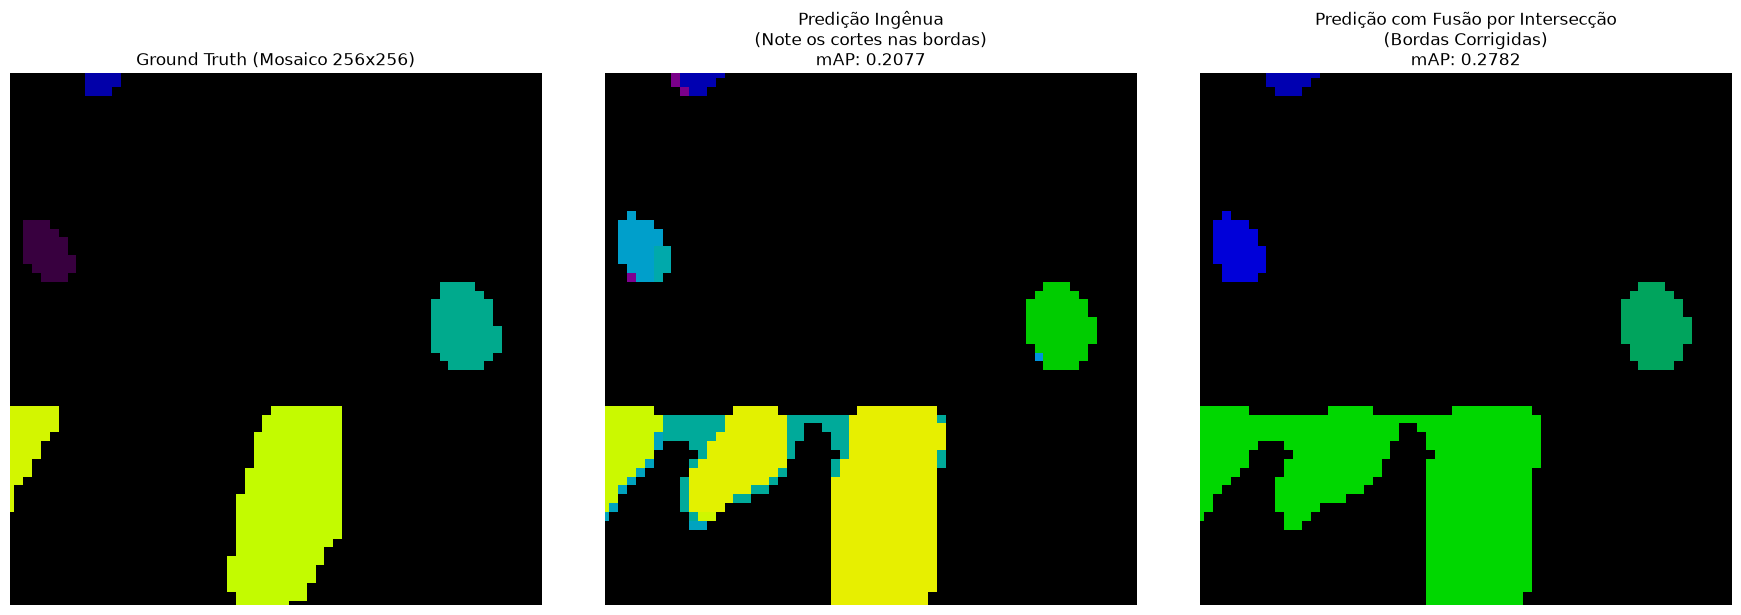

In [40]:
# 2. Inferência com Fusão (Depois da correção)
pred_fusion = mosaic_inference_with_fusion(real_model, mosaic_img, tile_size=128, overlap=32, device=device)
map_fusion, err_fusion, _ = calculate_instance_metrics(mosaic_inst, pred_fusion)

print(f"❌ ANTES (Ingênuo): mAP = {map_naive:.4f} | Erro de Contagem = {err_naive}")
print(f"✅ DEPOIS (Fusão) : mAP = {map_fusion:.4f} | Erro de Contagem = {err_fusion}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(mosaic_inst, cmap='nipy_spectral')
axes[0].set_title("Ground Truth (Mosaico 256x256)")
axes[0].axis('off')

axes[1].imshow(pred_naive, cmap='nipy_spectral')
axes[1].set_title(f"Predição Ingênua\n(Note os cortes nas bordas)\nmAP: {map_naive:.4f}")
axes[1].axis('off')

axes[2].imshow(pred_fusion, cmap='nipy_spectral')
axes[2].set_title(f"Predição com Fusão por Intersecção\n(Bordas Corrigidas)\nmAP: {map_fusion:.4f}")
axes[2].axis('off')



# Definindo a região do zoom (exemplo de uma janela de 60x60 pixels)
zoom_x_min, zoom_x_max = 90, 150
zoom_y_min, zoom_y_max = 90, 150

for ax in axes:
    ax.set_xlim(zoom_x_min, zoom_x_max)
    ax.set_ylim(zoom_y_max, zoom_y_min) # Y é invertido no imshow (de cima para baixo)

plt.tight_layout()
plt.show()